In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image
import torch
from torch import nn
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from tqdm.notebook import tqdm
from torchvision import transforms, datasets
from torchvision.io import read_image
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.model_selection import train_test_split

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [9]:
!cp -r drive/MyDrive/plant/PlantVillage /content/PlantVillage
path = "/content/PlantVillage"

In [10]:
print("Path to dataset files:", path)

Path to dataset files: /content/PlantVillage


Number of total classes: 15
Tomato_Late_blight
256
256


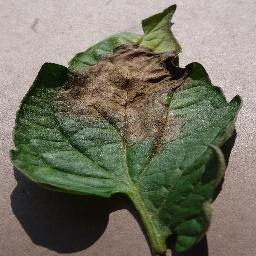

In [11]:
classes = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

class_name = random.choice(classes)
class_path = os.path.join(path, class_name)

valid_exts = (".jpg", ".jpeg", ".png")
img_files = [f for f in os.listdir(class_path) if f.lower().endswith(valid_exts)]

img_name = random.choice(img_files)
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(f"Number of total classes: {len(classes)}")
print(class_name)
print(img.height)
print(img.width)

img

(256, 256, 3)


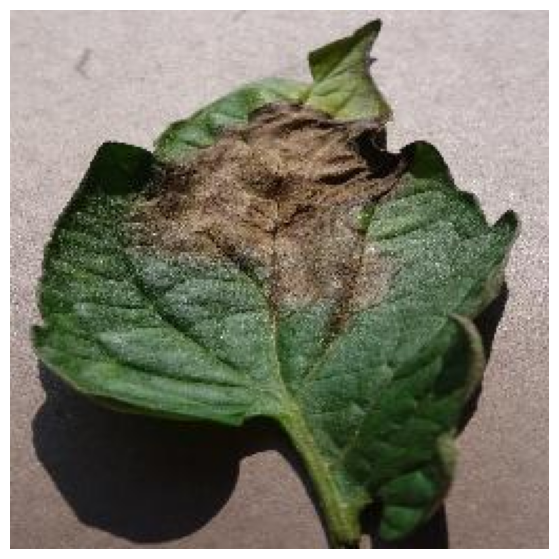

In [12]:
img_as_array = np.asanyarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.axis(False)

print(img_as_array.shape)

In [13]:
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [14]:
def visualize_transform(img_path, transform):
  img = Image.open(img_path)

  transformed_img = transform(img)

  if isinstance(transformed_img, torch.Tensor):
    transformed_img = transforms.ToPILImage()(transformed_img)

  fig, axes = plt.subplots(1, 2, figsize=(8,4))

  axes[0].imshow(img)
  axes[0].set_title("Original")
  axes[0].axis("off")

  axes[1].imshow(transformed_img)
  axes[1].set_title("Transformed")
  axes[1].axis("off")

  plt.show()

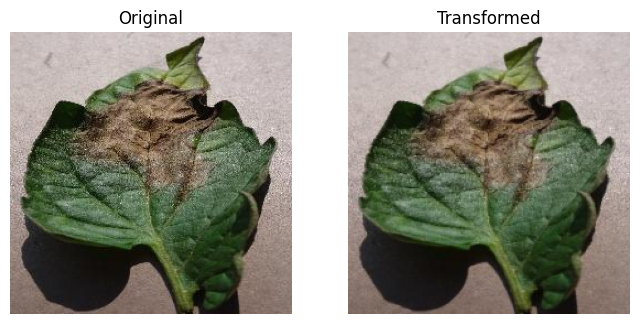

In [15]:
class_name = random.choice(classes)
classs_path = os.path.join(path, class_name)
img_name = random.choice(os.listdir(class_path))
imag_path= os.path.join(class_path, img_name)

visualize_transform(img_path, data_transform)

In [16]:
full_dataset = datasets.ImageFolder(root=path, transform=None)
full_dataset

Dataset ImageFolder
    Number of datapoints: 20678
    Root location: /content/PlantVillage

In [17]:
class_to_idx = full_dataset.class_to_idx
classes = list(class_to_idx.keys())
classes

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [18]:
idx_to_class = {value: key for key, value in class_to_idx.items()}
idx_to_class

{0: 'Pepper__bell___Bacterial_spot',
 1: 'Pepper__bell___healthy',
 2: 'Potato___Early_blight',
 3: 'Potato___Late_blight',
 4: 'Potato___healthy',
 5: 'Tomato_Bacterial_spot',
 6: 'Tomato_Early_blight',
 7: 'Tomato_Late_blight',
 8: 'Tomato_Leaf_Mold',
 9: 'Tomato_Septoria_leaf_spot',
 10: 'Tomato_Spider_mites_Two_spotted_spider_mite',
 11: 'Tomato__Target_Spot',
 12: 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 13: 'Tomato__Tomato_mosaic_virus',
 14: 'Tomato_healthy'}

In [19]:
targets = [label for _, label in full_dataset.samples]
print(f"Total images: {len(targets)}")

Total images: 20678


In [20]:
train_idx, test_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    random_state=42,
    stratify=targets
)

In [21]:
print(f"Number of Train images: {len(train_idx)} | Number of Test images: {len(test_idx)}")

Number of Train images: 16542 | Number of Test images: 4136


In [22]:
calc_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

calc_full = datasets.ImageFolder(root=path, transform=calc_transform)
calc_train = Subset(calc_full, train_idx)

In [23]:
def get_mean_std(dataset, batch_size=32, num_workers=2):
  loader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)
  rgb_sum = torch.zeros(3)
  rgb_sumsq = torch.zeros(3)
  count_pixels = 0

  for x, _ in loader:
    b, c, h, w = x.shape
    count_pixels += b * h * w
    rgb_sum += x.sum(dim=[0,2,3])
    rgb_sumsq += (x**2).sum(dim=[0,2,3])

  mean = rgb_sum / count_pixels
  std = torch.sqrt(rgb_sumsq / count_pixels - mean ** 2)
  return mean, std

In [25]:
# Mean & std (important code)
mean_tensor, std_tensor = get_mean_std(calc_train)
mean = mean_tensor.tolist()
std = std_tensor.tolist()

print("Mean:", mean)
print("Std:", std)

Mean: [0.4592483937740326, 0.4754590392112732, 0.41152873635292053]
Std: [0.18592999875545502, 0.1625351905822754, 0.2007875144481659]


In [26]:
mean = [0.45923691987991333, 0.4754456877708435, 0.4114924371242523]
std = [0.18601608276367188, 0.16261300444602966, 0.20084309577941895]

In [27]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [29]:
train_data_all = datasets.ImageFolder(root=path, transform=train_transform)
test_data_all = datasets.ImageFolder(root=path, transform=test_transform)

train_set = Subset(train_data_all, train_idx)
test_set = Subset(test_data_all, test_idx)

In [30]:
len(train_set), len(test_set)

(16542, 4136)

In [31]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(train_set, batch_size= BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_set, batch_size= BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [32]:
len(train_loader), len(test_loader)

(517, 130)

In [33]:

class ImageClassifierCNN(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.block1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.block2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.block3 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=128*28*28, out_features=512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(in_features=512, out_features=num_classes)
    )

  def forward(self, x):
    x = self.block1(x)
    x = self.block2(x)
    x = self.block3(x)
    x = self.classifier(x)
    return x
    # return self.classifier(self.block3(self.block2(self.block1(x))))


In [34]:
num_classes = 15

cnn_model = ImageClassifierCNN(num_classes=num_classes).to(device)
cnn_model

ImageClassifierCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_feature

In [35]:
# Create Loss, Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

#Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

#Early Stopping Parameters
patience = 3
early_stop_counter = 0
best_test_loss = float("inf")
best_model_path = "/content/drive/My Drive/cnn_model.pth"


#Move model to GPU if available
cnn_model = cnn_model.to(device)

# Training and Evaluation Loop
EPOCHS = 10

for epoch in range(EPOCHS):

  # Training Phase
  cnn_model.train()
  running_loss, correct, total = 0.0, 0, 0

  # tqdm progress bar
  for batch_idx, (X_batch, y_batch) in enumerate (tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    #forward pass
    y_pred = cnn_model(X_batch)
    loss = loss_fn(y_pred, y_batch)

    #backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #running metrics
    running_loss += loss.item()
    _, predicted = torch.max(y_pred, 1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

    #batch-wise loss print every 50 batches
    if batch_idx % 50 == 0:
        tqdm.write(f"Batch {batch_idx}: Loss={loss.item():.4f}")

  #Epoch-wise metrics
  train_acc = 100 * correct / total
  avg_loss = running_loss / len(train_loader)

  # Evaluation Phase
  cnn_model.eval()
  test_correct, test_total, test_loss_total = 0, 0, 0.0

  with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            test_pred = cnn_model(X_batch)
            test_loss = loss_fn(test_pred, y_batch)

            test_loss_total += test_loss.item()
            _, predicted = torch.max(test_pred, 1)
            test_total += y_batch.size(0)
            test_correct += (predicted == y_batch).sum().item()

  test_acc = 100 * test_correct / test_total
  avg_loss = test_loss_total / len(test_loader)

  #Learning rate scheduling
  scheduler.step(avg_loss)
  #print epoch summary
  print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}% | "
        f"Learning rate now: {optimizer.param_groups[0]['lr']}")

  #Early stopping check
  if avg_loss < best_test_loss:
    best_test_loss = avg_loss
    early_stop_counter = 0
    torch.save(cnn_model.state_dict(), best_model_path) #best model save
    print(f"Best model saved at epoch {epoch+1}")
  else:
    early_stop_counter += 1
    print(f"No improvement. Patience counter: {early_stop_counter}/{patience}")
    if early_stop_counter >= patience:
      print("Early stopping triggered!")
      break


Epoch 1/10:   0%|          | 0/517 [00:00<?, ?it/s]

Batch 0: Loss=2.7134
Batch 50: Loss=2.3300
Batch 100: Loss=2.1391
Batch 150: Loss=2.1224
Batch 200: Loss=1.4722
Batch 250: Loss=1.5732
Batch 300: Loss=1.5384
Batch 350: Loss=1.3550
Batch 400: Loss=0.7905
Batch 450: Loss=1.4018
Batch 500: Loss=0.3666
Epoch [1/10] | Train Loss: 0.9338 | Train Acc: 48.81% | Test Acc: 68.23% | Learning rate now: 0.001
Best model saved at epoch 1


Epoch 2/10:   0%|          | 0/517 [00:00<?, ?it/s]

Batch 0: Loss=1.1260
Batch 50: Loss=0.7337
Batch 100: Loss=0.8850
Batch 150: Loss=0.7199
Batch 200: Loss=0.7658
Batch 250: Loss=1.2548
Batch 300: Loss=1.2640
Batch 350: Loss=0.5755
Batch 400: Loss=0.6478
Batch 450: Loss=0.7934
Batch 500: Loss=0.5551
Epoch [2/10] | Train Loss: 0.6495 | Train Acc: 69.79% | Test Acc: 77.59% | Learning rate now: 0.001
Best model saved at epoch 2


Epoch 3/10:   0%|          | 0/517 [00:00<?, ?it/s]

...

Batch 0: Loss=0.4454
Batch 50: Loss=0.0575
Batch 100: Loss=0.1281
Batch 150: Loss=0.2110
Batch 200: Loss=0.3522
Batch 250: Loss=0.3783
Batch 300: Loss=0.2242
Batch 350: Loss=0.2498
Batch 400: Loss=0.3673
Batch 450: Loss=0.2784
Batch 500: Loss=0.3264
Epoch [8/10] | Train Loss: 0.2818 | Train Acc: 88.87% | Test Acc: 90.33% | Learning rate now: 0.001
Best model saved at epoch 8


Epoch 9/10:   0%|          | 0/517 [00:00<?, ?it/s]

Batch 0: Loss=0.4116
Batch 50: Loss=0.2417
Batch 100: Loss=0.2455
Batch 150: Loss=0.3713
Batch 200: Loss=0.1880
Batch 250: Loss=0.1378
Batch 300: Loss=0.5748
Batch 350: Loss=0.4570
Batch 400: Loss=0.2020
Batch 450: Loss=0.1768
Batch 500: Loss=0.2803
Epoch [9/10] | Train Loss: 0.1775 | Train Acc: 91.10% | Test Acc: 94.05% | Learning rate now: 0.001
Best model saved at epoch 9


Epoch 10/10:   0%|          | 0/517 [00:00<?, ?it/s]

Batch 0: Loss=0.1196
Batch 50: Loss=0.4383
Batch 100: Loss=0.1035
Batch 150: Loss=0.2876
Batch 200: Loss=0.4090
Batch 250: Loss=0.2901
Batch 300: Loss=0.2777
Batch 350: Loss=0.3651
Batch 400: Loss=0.5614
Batch 450: Loss=0.1780
Batch 500: Loss=0.1642
Epoch [10/10] | Train Loss: 0.1787 | Train Acc: 91.91% | Test Acc: 94.08% | Learning rate now: 0.001
No improvement. Patience counter: 1/3


In [36]:
#Load Trained model
num_classes = num_classes
cnn_model = ImageClassifierCNN(num_classes=num_classes)
cnn_model.load_state_dict(torch.load(best_model_path, map_location=device))
cnn_model = cnn_model.to(device)
cnn_model.eval()   # put into inference mode
print("Model loaded and ready for inference.")

Model loaded and ready for inference.


In [37]:
#define same transformations
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [38]:
#Load an image for testing
pred_img_path = "/content/PlantVillage/Tomato_Leaf_Mold/02a29ab9-8cba-47a0-bc2f-e7af7dbae149___Crnl_L.Mold 7165.JPG"
pred_img = read_image(pred_img_path).type(torch.float32)
pred_img

tensor([[[101., 102., 105.,  ...,  84.,  99., 102.],
         [103.,  96.,  94.,  ..., 100., 108., 100.],
         [ 97.,  98.,  92.,  ...,  95., 110., 111.],
         ...,
         [136., 119., 118.,  ..., 120., 118., 118.],
         [127., 113., 114.,  ..., 130., 127., 126.],
         [122., 118., 125.,  ..., 126., 127., 126.]],

        [[102., 103., 106.,  ...,  85., 100., 103.],
         [104.,  97.,  95.,  ..., 101., 109., 101.],
         [ 98.,  99.,  93.,  ...,  96., 111., 112.],
         ...,
         [141., 124., 123.,  ..., 125., 123., 123.],
         [132., 118., 119.,  ..., 135., 132., 131.],
         [127., 123., 130.,  ..., 131., 132., 131.]],

        [[122., 123., 126.,  ..., 103., 118., 121.],
         [124., 117., 115.,  ..., 119., 127., 119.],
         [118., 119., 113.,  ..., 114., 129., 130.],
         ...,
         [161., 144., 143.,  ..., 145., 143., 143.],
         [152., 138., 139.,  ..., 155., 152., 151.],
         [147., 143., 150.,  ..., 151., 152., 151.]]]

In [39]:
#load image with PIL
pred_img = Image.open(pred_img_path)

#apply transforms
pred_img = test_transform(pred_img)
pred_img = pred_img.unsqueeze(0).to(device)

In [40]:
#Prediction
cnn_model.eval()
with torch.inference_mode():
  prediction = cnn_model(pred_img)
prediction

tensor([[ -8.4596,  -9.4597,  -8.4628,  -7.7612, -20.1720, -16.3017,  -4.3595,
           0.9741,   9.6287,   3.7823,  -8.1985,  -6.3630, -15.1335,  -1.5176,
          -4.4838]], device='cuda:0')

In [41]:
#prediction probabilities using softmax
pred_probabilities = torch.softmax(prediction, dim=1)

#Get the prediction class index
pred_idx = torch.argmax(pred_probabilities, dim=1).item()

#Get the prediction class label
pred_label = idx_to_class[pred_idx]

#print results
print(f"Prediction probabilities:", pred_probabilities.squeeze().tolist())
print(f"Predicted class index:", pred_idx)
print(f"Predicted class label:", pred_label)

Prediction probabilities: [1.3900530504429298e-08, 5.112851475530533e-09, 1.3856033653780742e-08, 2.7946427394454076e-08, 1.1385988994087187e-13, 5.46049924027292e-12, 8.388158789784939e-07, 0.00017378981283400208, 0.9969285130500793, 0.002881481312215328, 1.804715132891488e-08, 1.1312249625916593e-07, 1.7562340470789195e-11, 1.4385089343704749e-05, 7.407566613437666e-07]
Predicted class index: 8
Predicted class label: Tomato_Leaf_Mold
